## Setup

In [145]:
# change into the src directory
import git
import os

repo = git.Repo('.', search_parent_directories=True)
os.chdir(repo.working_tree_dir)

In [146]:
from tapas_gmm_modified.policy.models.tpgmm import ModelType, TPGMM, ReconstructionStrategy, FittingStage, InitStrategy, _xdx_to_tangent, TPGMMConfig, AutoTPGMMConfig, AutoTPGMM, FrameSelectionConfig, DemoSegmentationConfig, CascadeConfig
# import lovely_tensors as lt
# lt.monkey_patch()
from lovely_numpy import lo
import matplotlib.pyplot as plt

import pathlib
#from pbdlib.utils.jupyter_utils import *
import numpy as np

from conf._machine import data_naming_config as machine_data_naming_config
from tapas_gmm_modified.dataset.demos import Demos, PartialFrameViewDemos
import tapas_gmm_modified.policy.models.tpgmm
from tapas_gmm_modified.utils.misc import load_scene_data, DataNamingConfig
from tapas_gmm_modified.utils.logging import setup_logger  # noqa: F401
from tapas_gmm_modified.viz.gmm import plot_log_map_quaternions, plot_hmm_transition_matrix

%matplotlib inline

%load_ext autoreload
%autoreload 2

data_root = pathlib.Path(machine_data_naming_config.data_root).resolve()
data_root = data_root.parent / data_root.stem

np.set_printoptions(precision=2)

plt.style.use('default')

from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [147]:
#task = 'TurnOnLight'
serie = 'demos'
task = 'Test1'
path = data_root / task / serie

data_config = DataNamingConfig(
    feedback_type=None,
    task=None,
    data_root=None,
    path=path,
)

scene_data = load_scene_data(data_config)
print(scene_data.sample_data_point_with_ground_truth(cam="wrist"))


SingleCamSceneObservation(
    action=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    depth=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
    ee_pose=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    extr=Tensor(shape=torch.Size([4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
    feedback=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
    intr=Tensor(shape=torch.Size([3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
    mask=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.uint8, is_shared=False),
    object_poses=TensorDict(
        fields={
            base__button: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__drawer: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__slide: Tensor(shape=torch.Size([7]), 

In [148]:
gt_pose_config = {
    #'indeces': [0,2,3,4],
}

gt_kp_config = {
    'encoder_name': 'demos_keypoints_gt_encoder-world',
    'cam': 'front',
}

kp_config = {
    'encoder_name': 'demos_vit_keypoints_encoder',
    'encoding_name': 'gtcopy',
}


In [149]:
observations = scene_data.get_demos(**gt_pose_config)
print(observations[0].keys())
print(observations[0])
n_obs = len(observations)

demo_meta_data = {
    'path': path
}

data_kwargs = dict(
    meta_data=demo_meta_data,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True
)

demos = Demos(observations, **data_kwargs)
print(demos)

_LazyStackedTensorDictKeysView(['action', 'cameras', 'ee_pose', 'feedback', 'gripper_state', 'joint_pos', 'joint_vel', 'object_poses', 'object_states'],
    include_nested=False,
    leaves_only=False)
SceneObservation(
    action=Tensor(shape=torch.Size([98, 7]), device=cpu, dtype=torch.float32, is_shared=False),
    cameras=LazyStackedTensorDict(
        fields={
            _order: CameraOrder(
                order=('wrist',),
                batch_size=torch.Size([98]),
                device=None,
                is_shared=False),
            wrist: SingleCamObservation(
                depth=Tensor(shape=torch.Size([98, 256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
                extr=Tensor(shape=torch.Size([98, 4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                intr=Tensor(shape=torch.Size([98, 3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                rgb=Tensor(shape=torch.Size([98, 3, 256, 256]), device=cpu, dtype=to

In [ ]:
tag="release"

tpgmm_config = TPGMMConfig(
    n_components=10,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=False,  # Use rotation aswell?
    add_gripper_action=True,
    heal_time_variance=False,
    reg_shrink=1e-2, # 1e-2 is 0.01
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,

    em_steps=50,
)

frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    rel_score_threshold=0.75,
    use_bic=False, #Does prune segmentation
    drop_redundant_frames=True,
    gt_frames=[[0,1],[0,1]]

)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    velocity_threshold=0.002,
    components_prop_to_len=True,
    min_end_distance=10,
    repeat_final_step=10,
)

cascade_config = CascadeConfig()

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [151]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2025-08-16 00:38:58.223 | INFO     |  Fitting AutoTPGMM
2025-08-16 00:38:58.224 | INFO     |  Segmenting trajectories


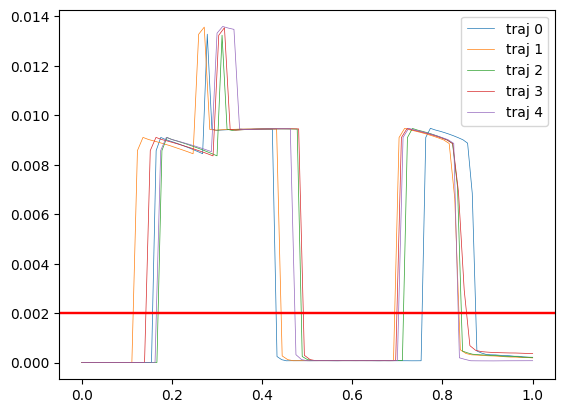

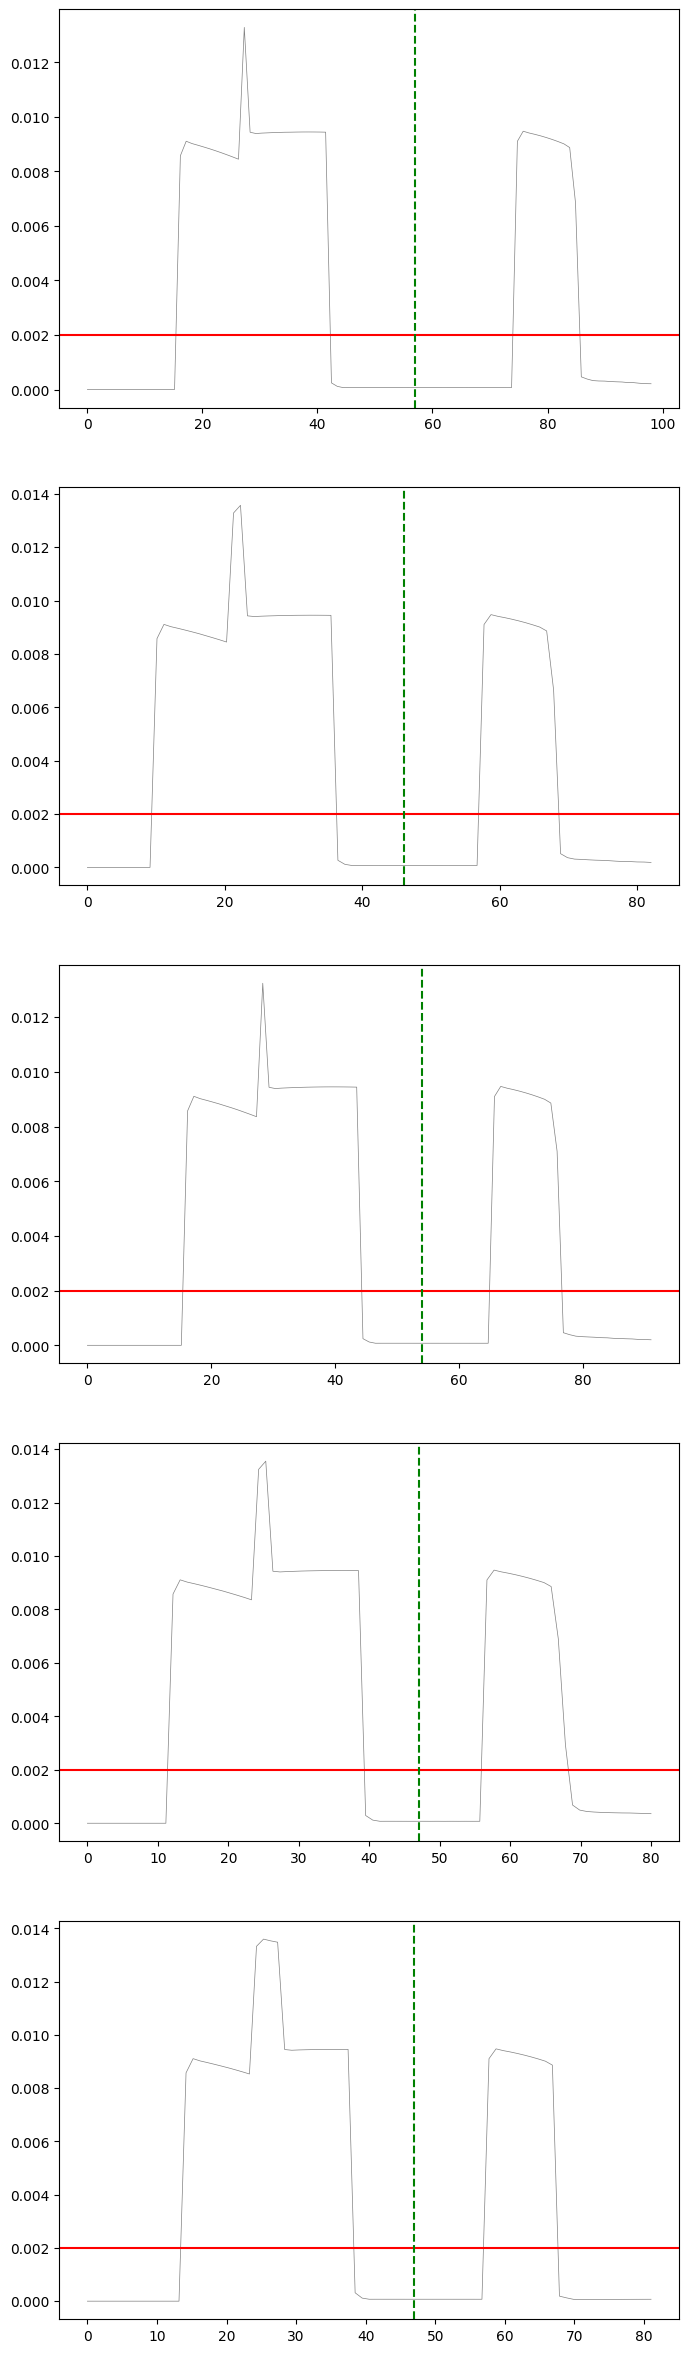

2025-08-16 00:38:58.448 | INFO     |  Creating segement of demos.
2025-08-16 00:38:58.450 | INFO     |  Creating segement of demos.
2025-08-16 00:38:58.452 | INFO     |  ... created 2 segments
2025-08-16 00:38:58.452 | INFO     |    Fitting candidate frame 1/10
2025-08-16 00:38:58.452 | INFO     |    Creating partial frame view of demos.
2025-08-16 00:38:58.452 | INFO     |    Changing number of components to 9


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2025-08-16 00:38:58.544 | INFO     |    Fitting candidate frame 2/10
2025-08-16 00:38:58.544 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2025-08-16 00:38:58.662 | INFO     |    Fitting candidate frame 3/10
2025-08-16 00:38:58.662 | INFO     |    Creating partial frame view of demos.


...

2025-08-16 00:39:00.730 | INFO     |  base__switch score (rel):     -0 (0.069)
2025-08-16 00:39:00.731 | INFO     |  Creating partial frame view of demos.
2025-08-16 00:39:00.731 | INFO     |  Segmented trajs into 2 segments
2025-08-16 00:39:00.733 | INFO     |  Frame score (abs):
            ee_init  base__button  base__drawer  base__slide  base__switch  \
Segment 0 -0.247899     -0.247899     -0.005187    -0.004414     -0.009591   
Segment 1 -0.246799     -0.246754     -0.002099    -0.001489     -0.016996   

           block_blue  block_pink  block_red       led  lightbulb  
Segment 0   -0.001318   -0.000015  -0.000022 -0.247899  -0.247899  
Segment 1   -0.000725   -0.000015  -0.000069 -0.246754  -0.246754  
2025-08-16 00:39:00.737 | INFO     |  Frame score (rel):
           ee_init  base__button  base__drawer  base__slide  base__switch  \
Segment 0      1.0      1.000000      0.020923     0.017806      0.038689   
Segment 1      1.0      0.999816      0.008503     0.006034      0.0

Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/6 [00:00<?, ?it/s]

((array([[2.81e+023, 2.81e+023, 1.03e+023, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [1.05e+022, 2.71e+022, 5.67e+022, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [4.13e+015, 6.37e+016, 7.70e+017, ..., 4.33e-229, 1.23e-232,
          2.73e-236],
         ...,
         [3.20e-091, 3.57e-087, 2.33e-083, ..., 2.32e-010, 2.52e-014,
          1.61e-018],
         [6.70e-261, 1.41e-255, 2.25e-250, ..., 4.24e+014, 1.61e+013,
          4.68e+011],
         [3.52e-246, 1.00e-243, 2.58e-241, ..., 1.23e+020, 8.90e+019,
          5.86e+019]]),
  array([[4.12e+020, 4.11e+020, 1.63e+020, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [4.23e+018, 7.28e+018, 1.04e+019, ..., 8.07e-104, 1.04e-106,
          1.12e-109],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 3.29e-026, 2.01e-030,
          7.93e-035],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 8.04e+001, 5.99e-001,
          3.48e-003],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 6.43e+017, 8.98e

In [152]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.INIT,))


2025-08-16 00:39:01.149 | INFO     |  Did not specify time_based, deciding automatically.


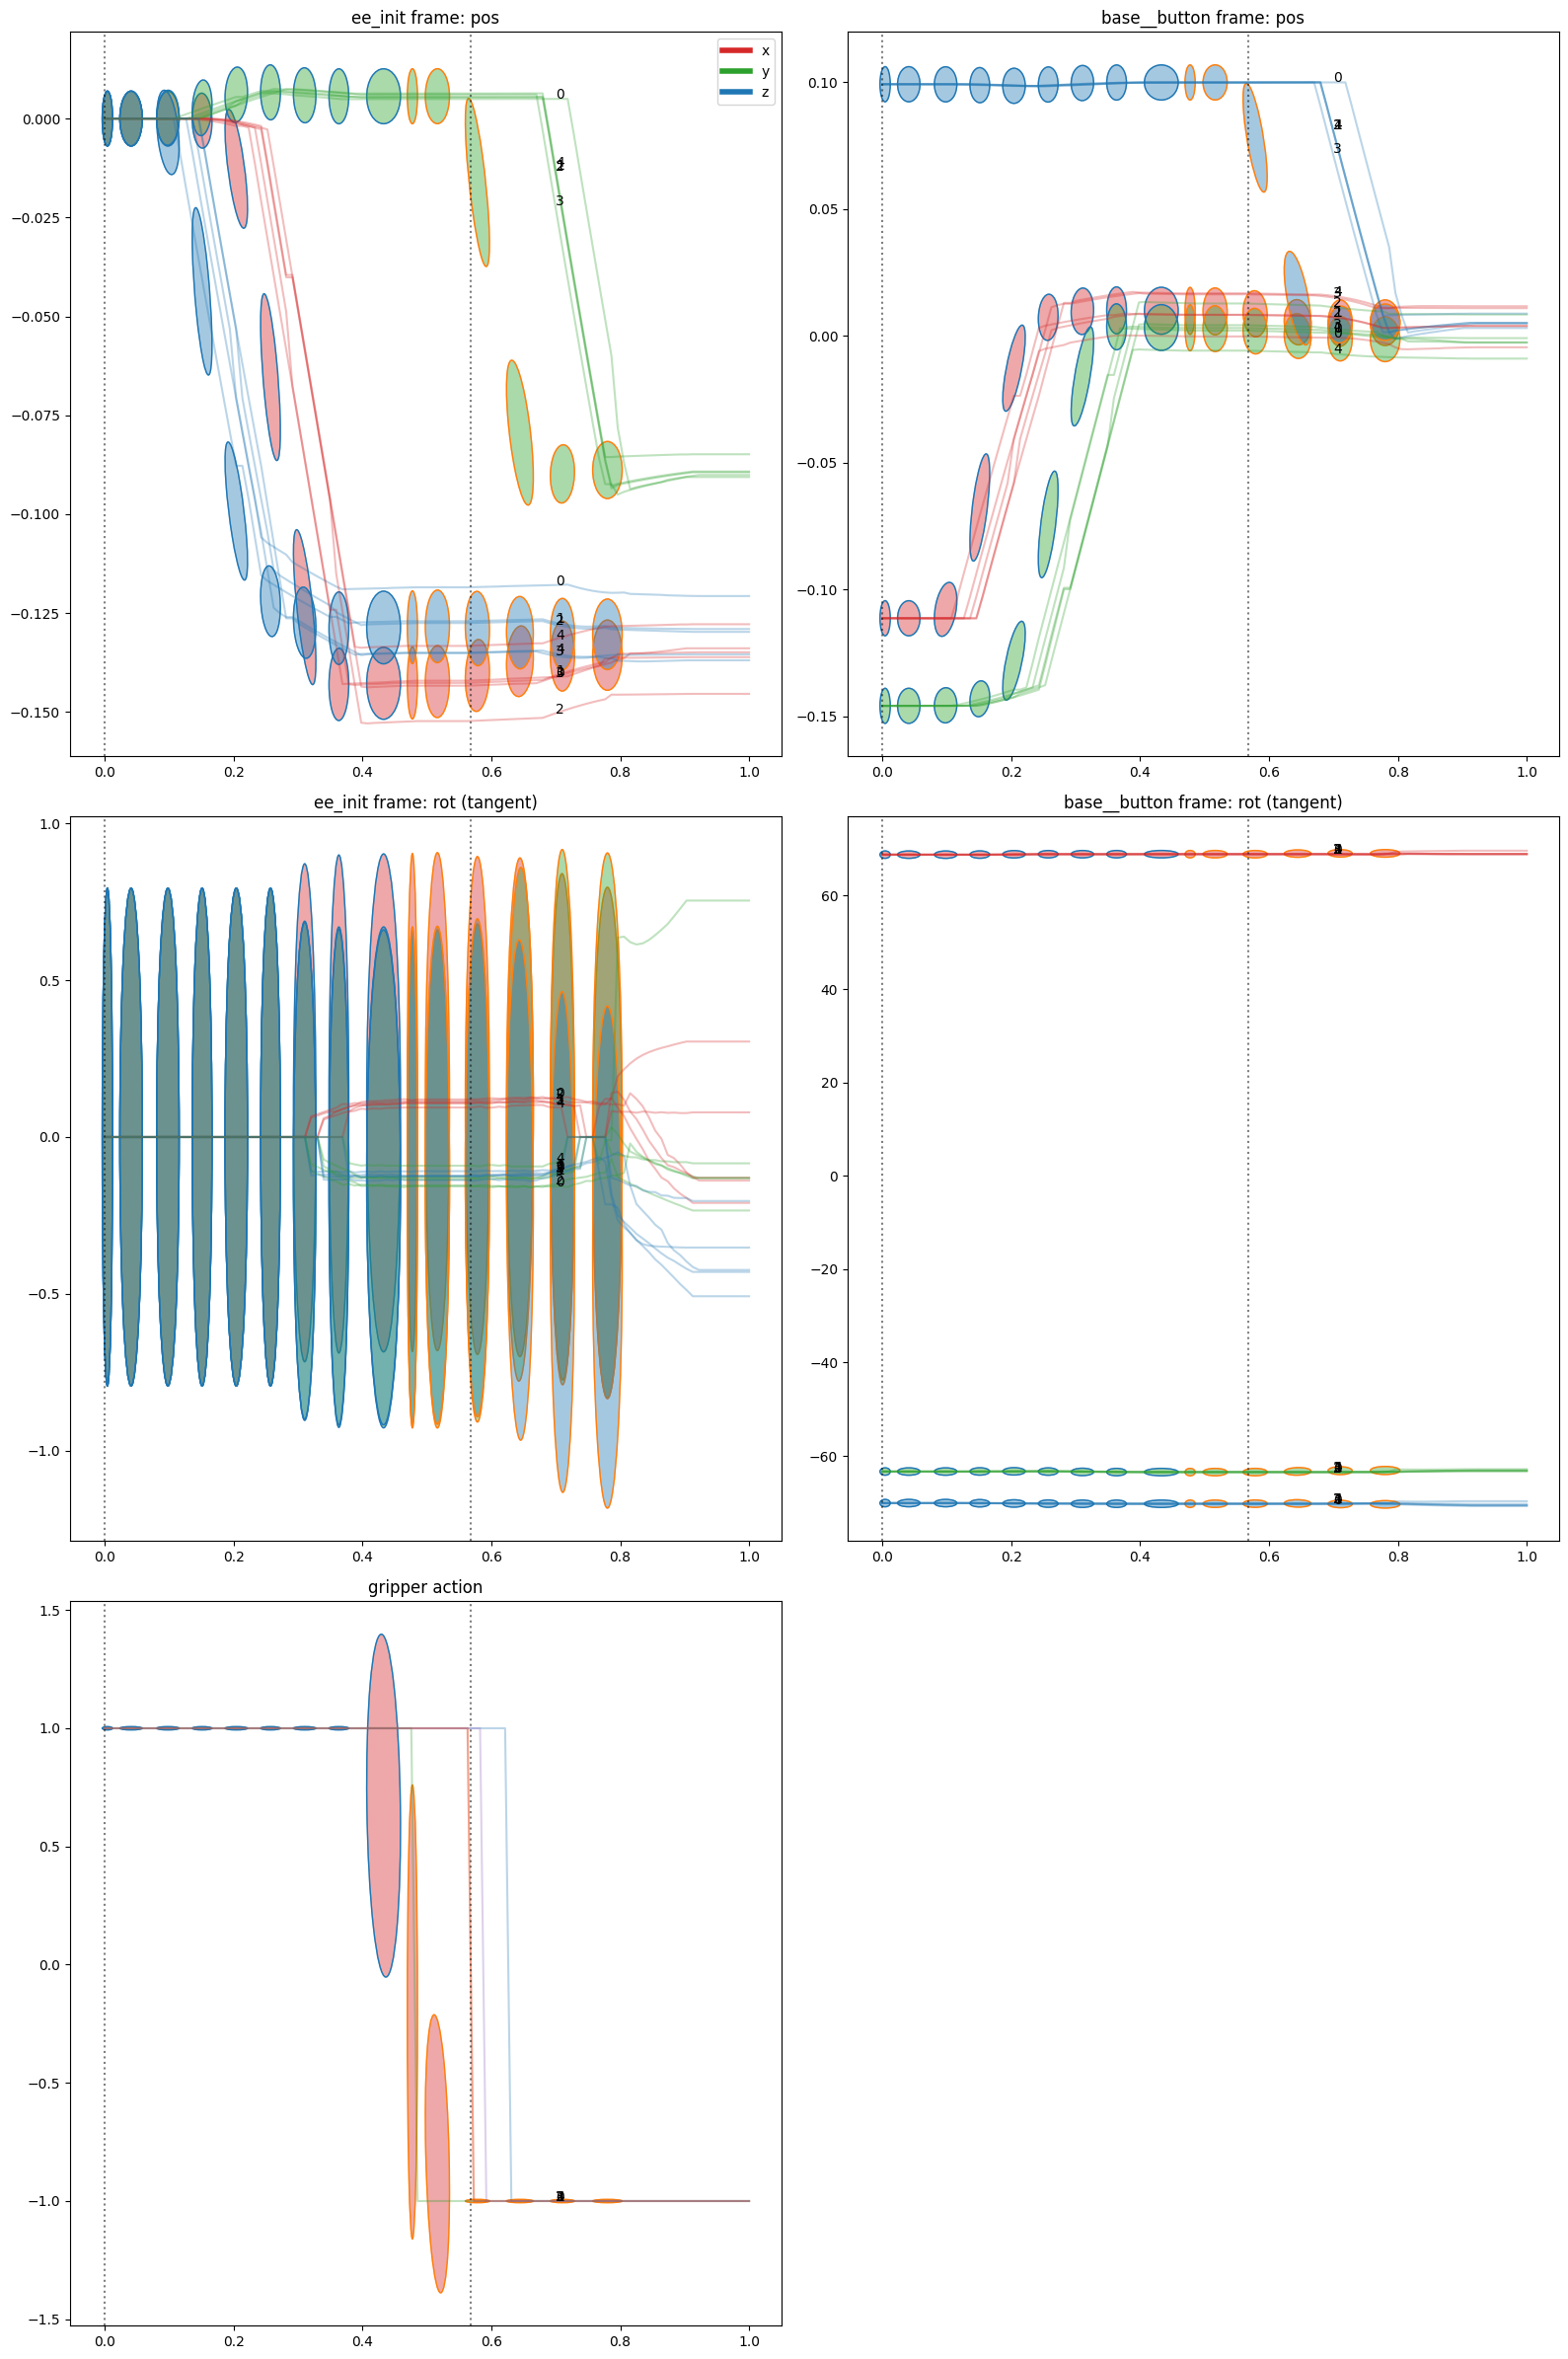

In [153]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [154]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2025-08-16 00:39:02.185 | INFO     |  Fitting AutoTPGMM


Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[1.00e+000, 1.00e+000, 1.00e+000, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 1.85e-024, 3.08e-017, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 0.00e+000, 1.33e-051, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         ...,
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 8.51e-189, 9.89e-211,
          5.69e-216],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 3.51e-103, 3.72e-119,
          2.30e-135],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 1.00e+000, 1.00e+000,
          1.00e+000]]),
  array([[1.00e+000, 1.00e+000, 1.00e+000, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 4.53e-227, 1.47e-179, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 0.00e+000, 8.26e-250, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 1.25e-244, 7.76e-271,
          1.53e-278],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 5.10e-141, 3.20e

2025-08-16 00:39:29.362 | INFO     |  Did not specify time_based, deciding automatically.


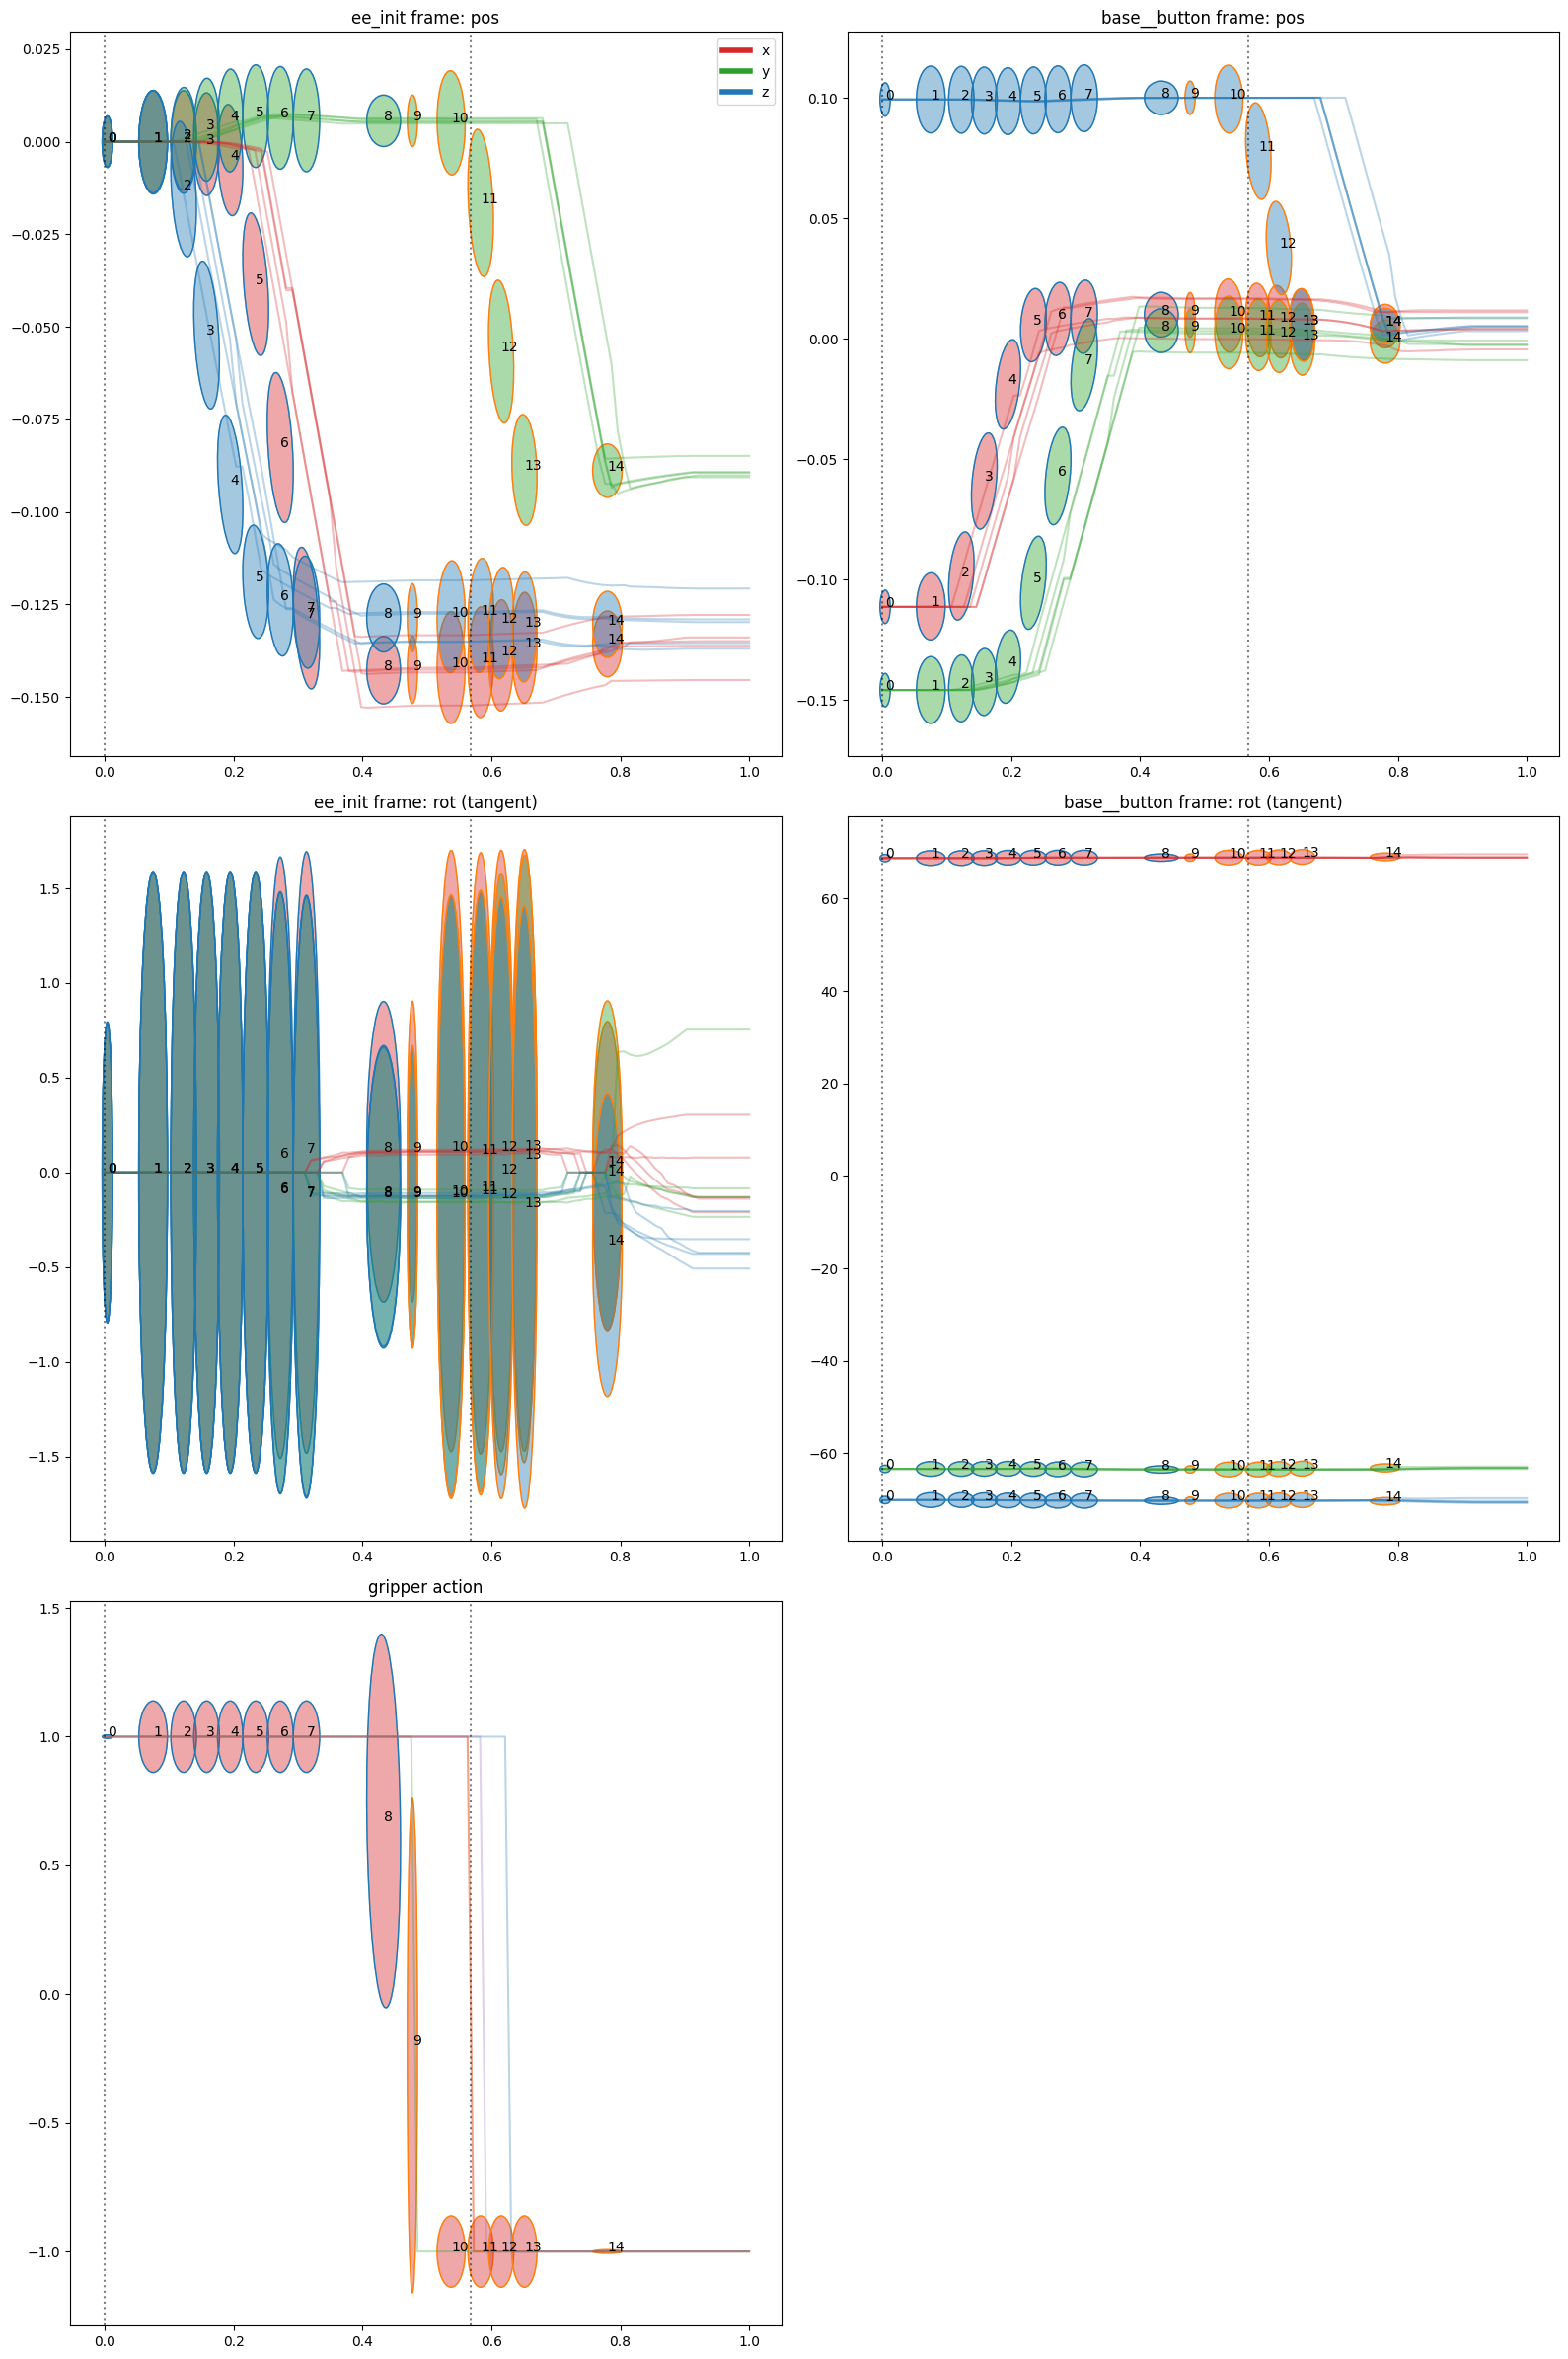

In [155]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

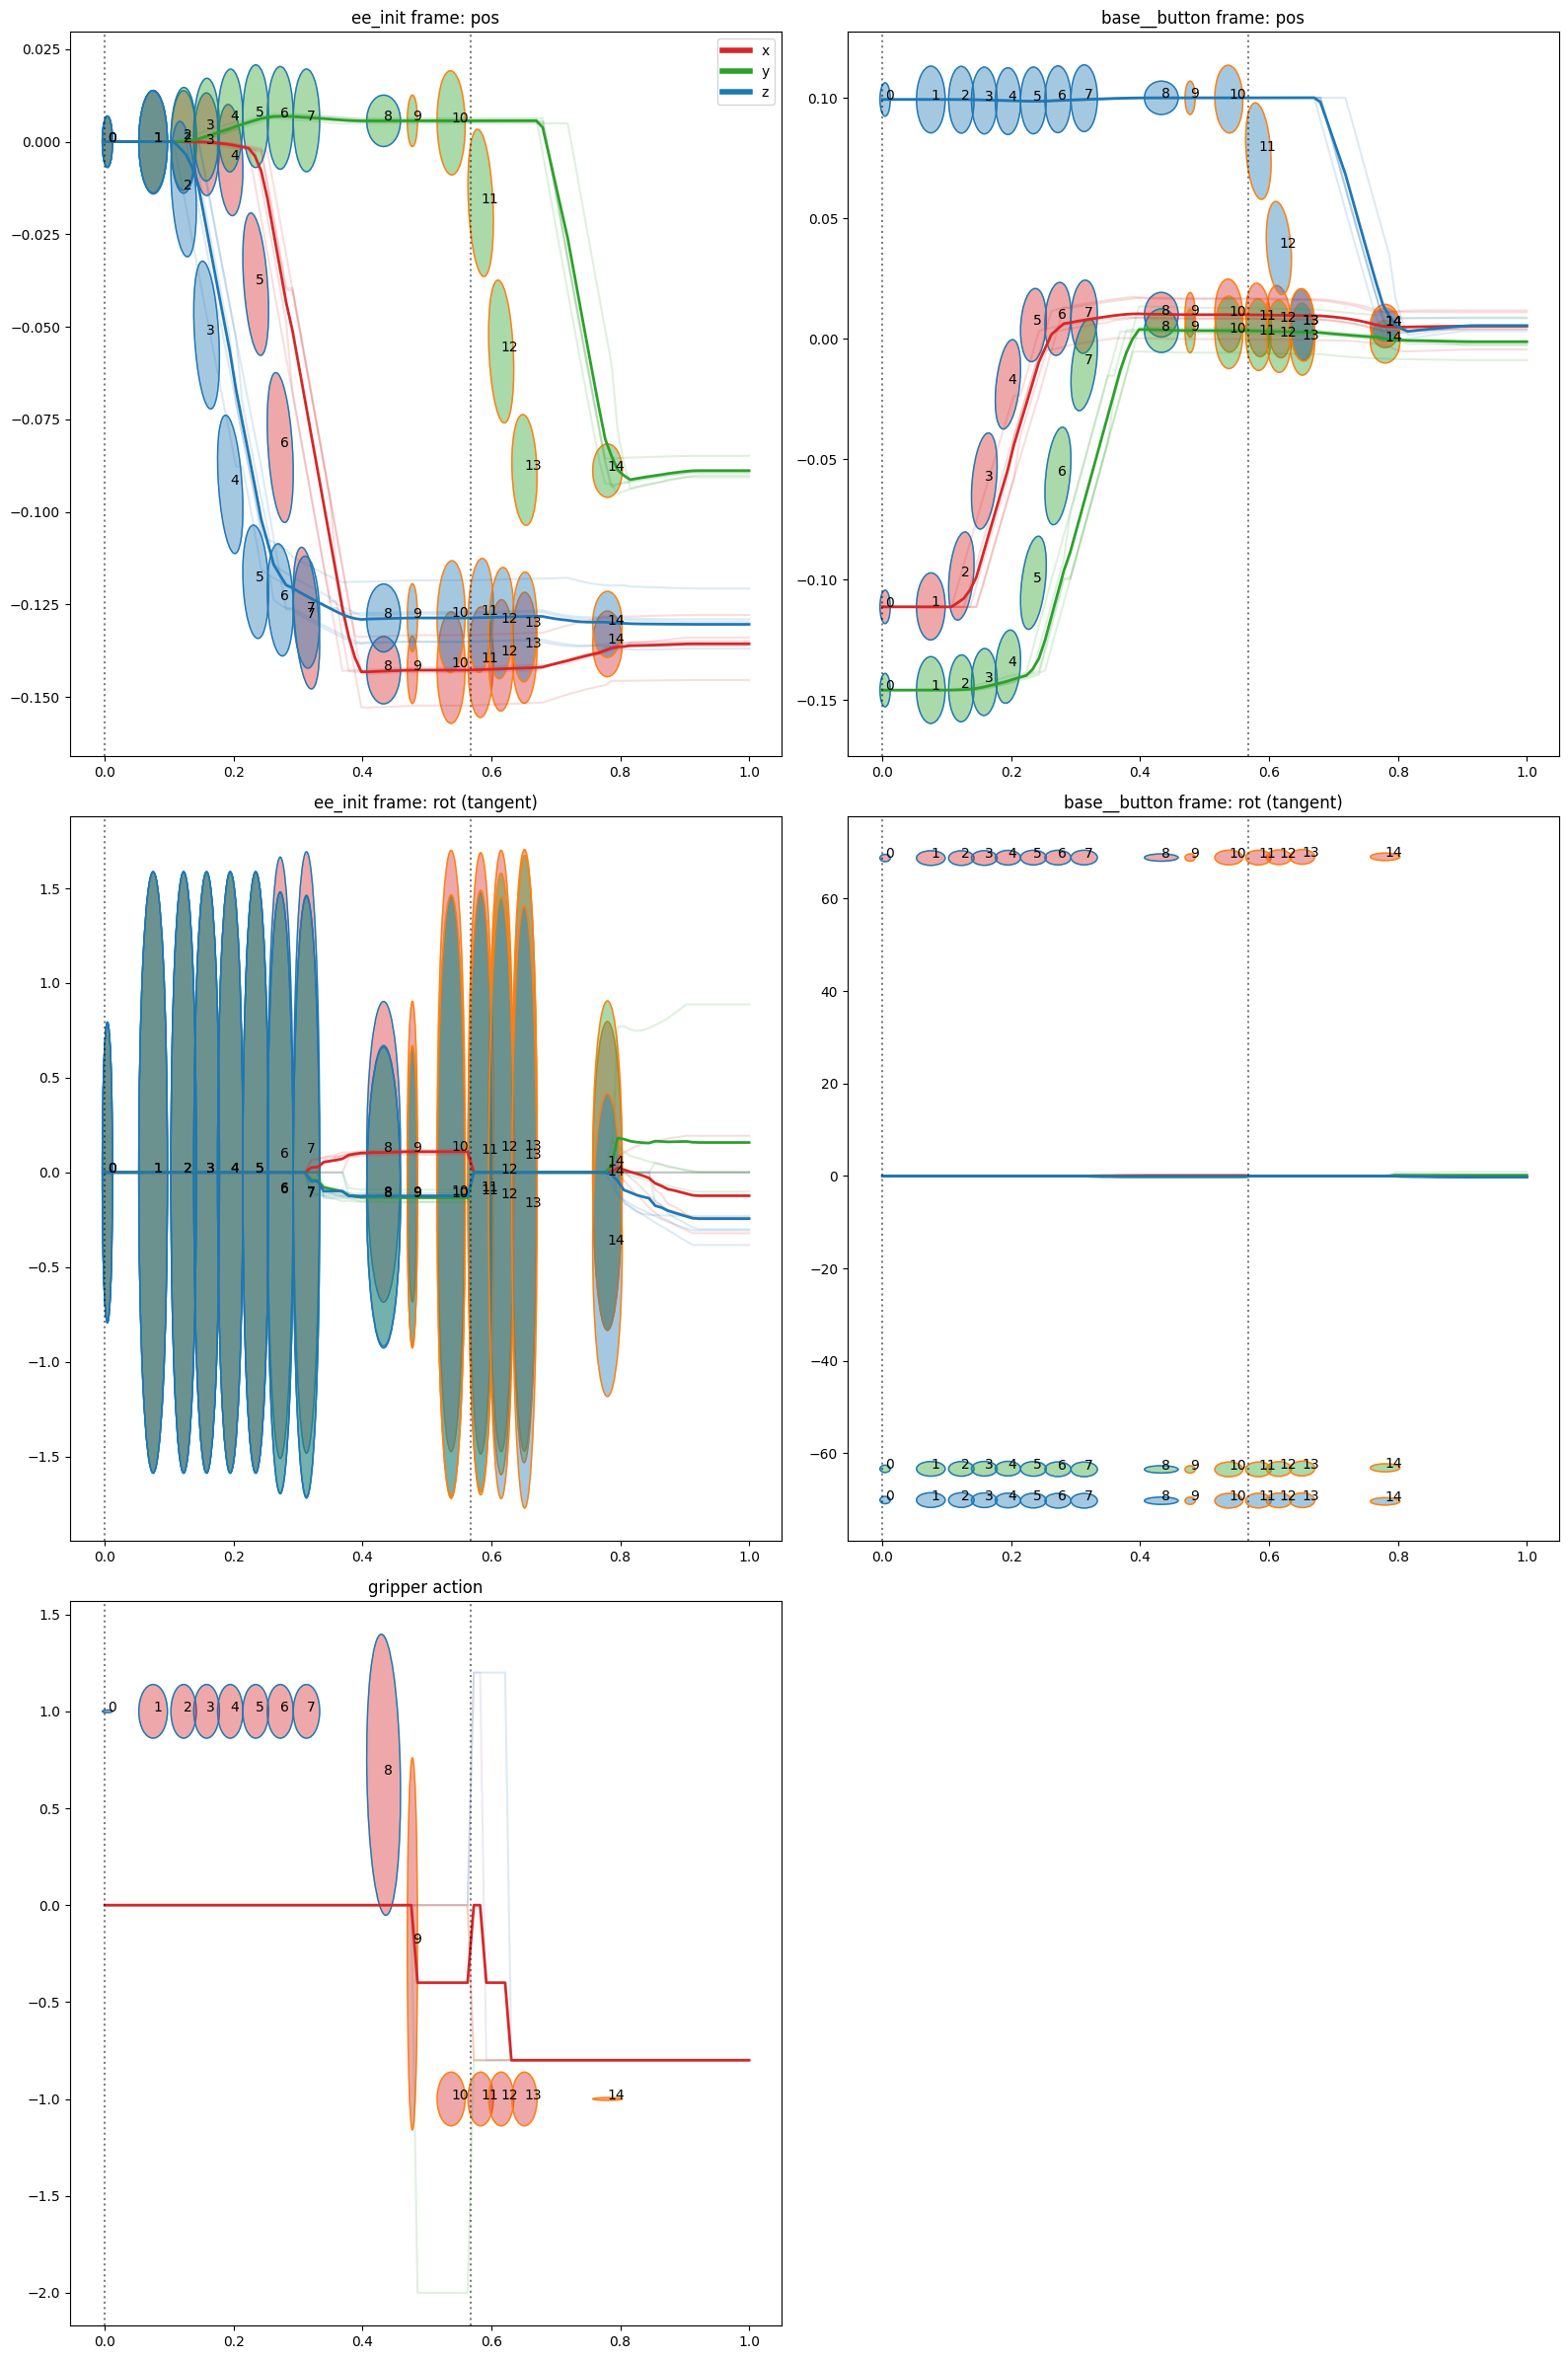

In [156]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=True, per_segment=False, gaussian_mean_only=False, plot_traj_means=True, time_based=True)

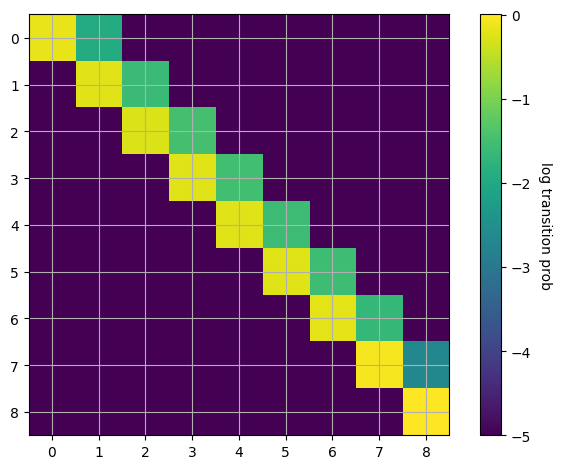

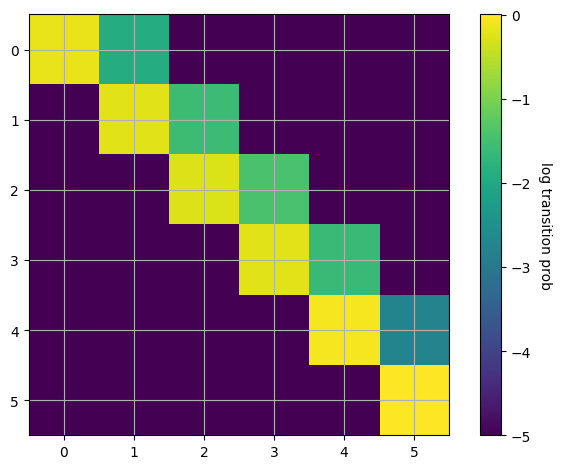

In [157]:
atpgmm.plot_hmm_transition_matrix()

In [158]:
atpgmm.to_disk(data_root / task / f'{serie}_gmm_policy-{tag}.pt')

In [159]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=tapas_gmm_modified.policy.models.tpgmm.ReconstructionStrategy.GMR,
    use_ss=False)


2025-08-16 00:39:41.430 | INFO     |  Caculated segment transition probabilities: (array([[4.83e-09]]),)
2025-08-16 00:39:41.430 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-16 00:39:41.491 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

GMR:   0%|          | 0/5 [00:00<?, ?it/s]

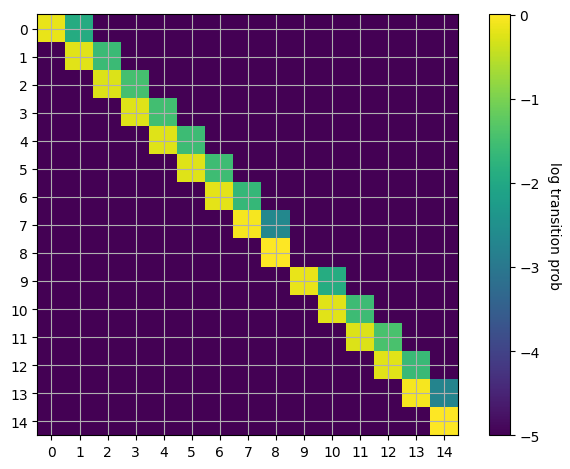

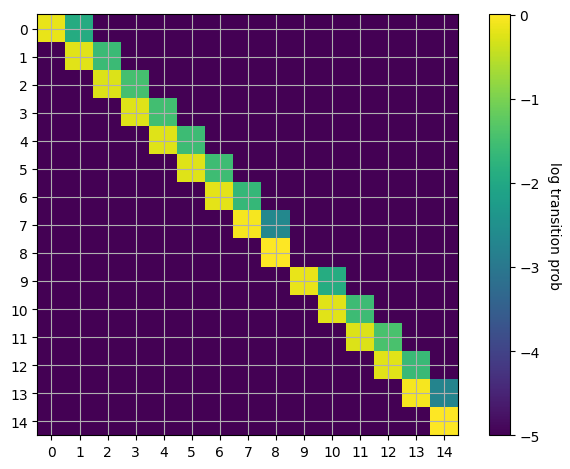

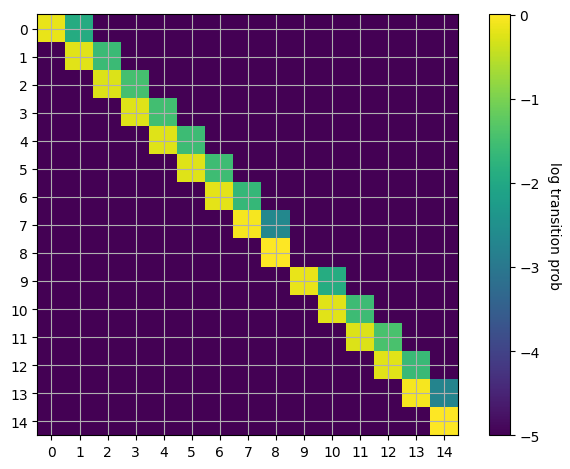

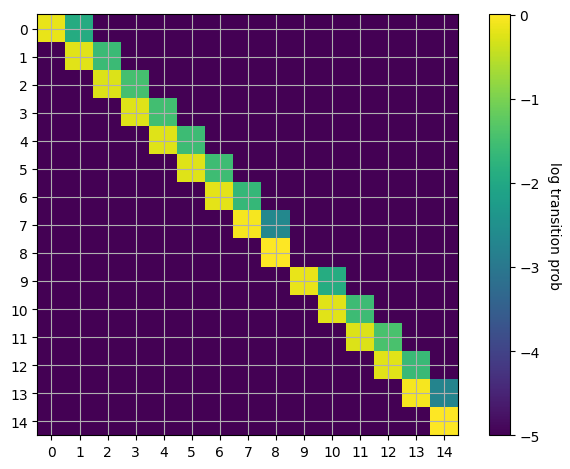

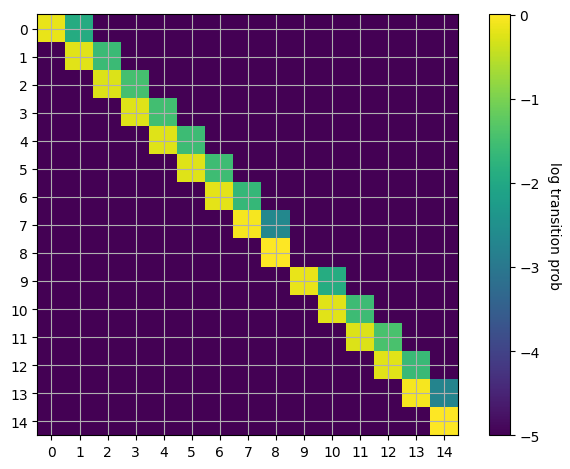

In [160]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2025-08-16 00:39:43.326 | INFO     |  Taking frame origins from demos.


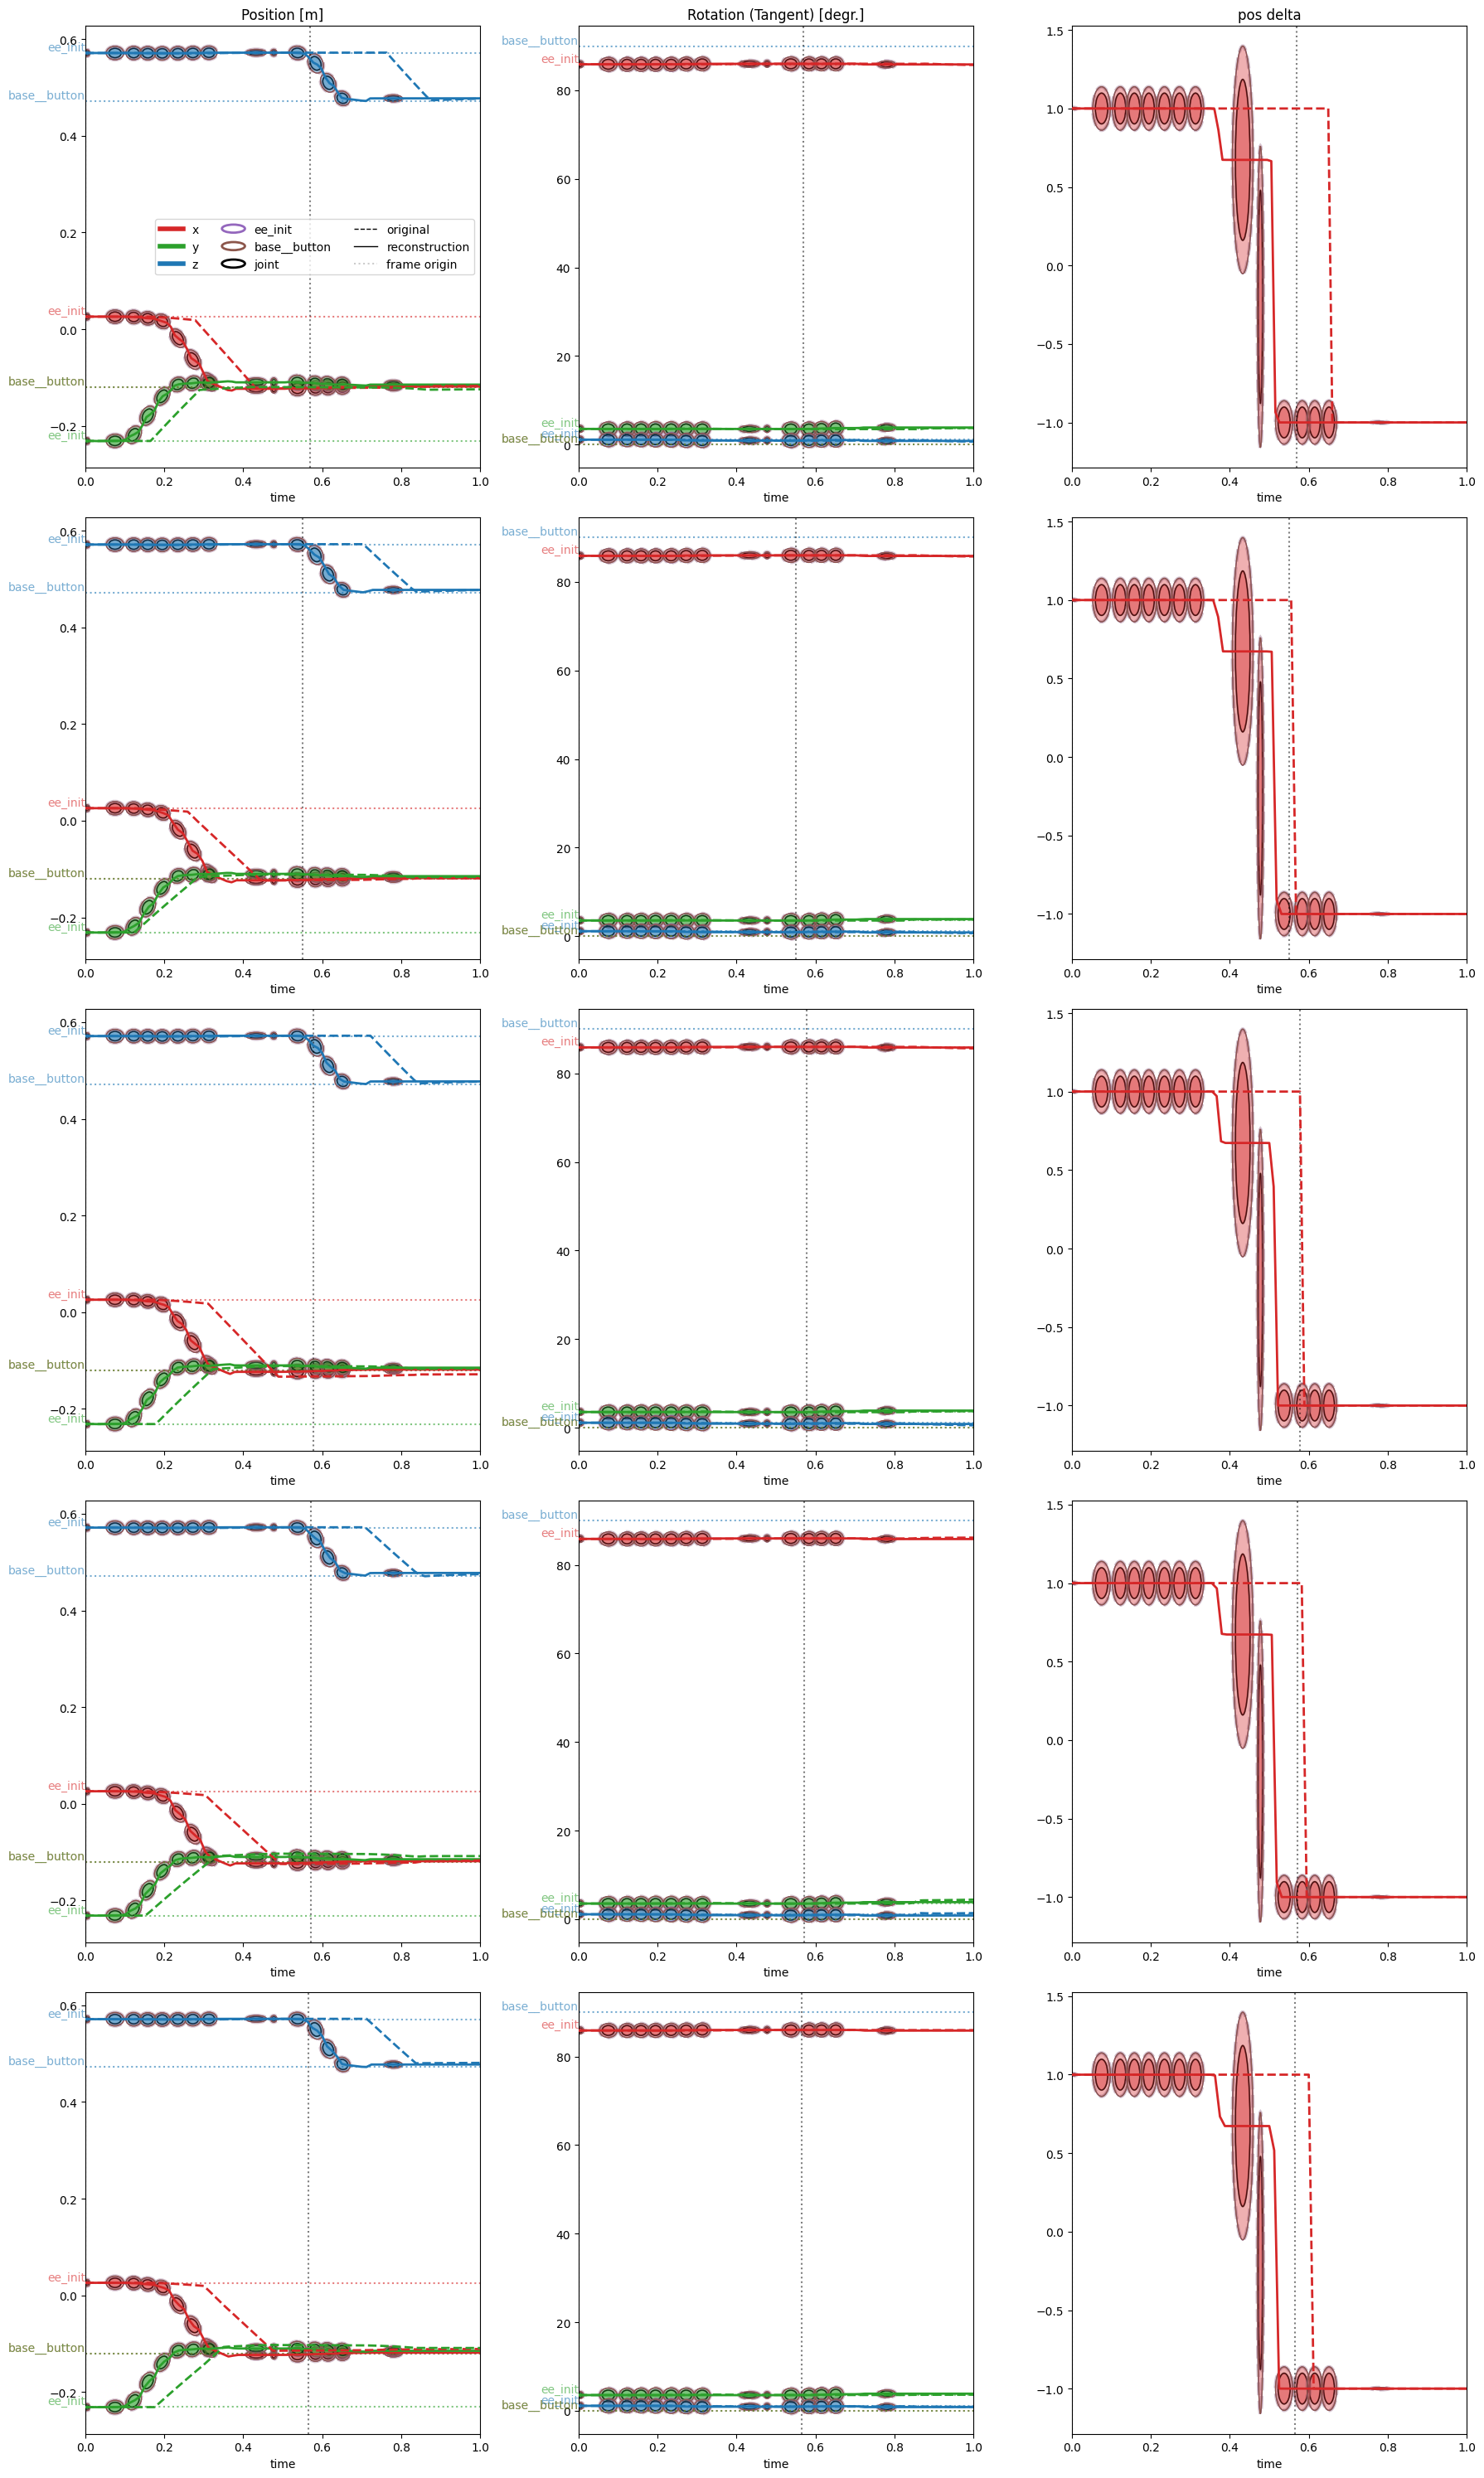

In [161]:
atpgmm.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [162]:
atpgmm.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=True,
    per_segment=False,
)

2025-08-16 00:39:48.440 | INFO     |  Taking frame origins from demos.


AttributeError: 'tuple' object has no attribute 'np_to_manifold_to_np'